# Participant sample composition

Reproduce Figure 1 and inspect the participant counts behind each bar.

**Input:** `data/processed/figure_inputs/composition/*_sample_metadata.csv`, included and regenerated by notebook 09. **Outputs:** `outputs/figures/Fig1.pdf` and the plotting data and sample counts in `outputs/tables/composition`.

**Run or explore:** run all cells in a fresh kernel. The bundled inputs are sufficient. Colors and labels are local to this notebook. The age and self-placement codes below are study definitions, so changing them changes the analysis sample.

Each participant contributes once per panel. Both rows require a consistent reported age of 19–120 in Chile or category 2–7 (20+) in France and Brazil. The indivisible 10–19 category is excluded in full. Unknown ages remain eligible for model estimation but cannot enter these demographic panels. Each panel requires consistency only in the variables it displays. Sex is not required for the ideological-identification panel. Percentages describe the participating samples.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
assert (ROOT / "data/raw").is_dir(), "Open from the project root or notebooks directory."

INPUT = ROOT / "data/processed/figure_inputs/composition"
assert INPUT.is_dir(), "Start in the package root or notebooks folder."
OUTPUT = ROOT / "outputs/figures"
TABLES = ROOT / "outputs/tables/composition"
OUTPUT.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)


## Select consistent records and count participants

`unique_consistent` collapses repeated identical responses and rejects a participant if the fields needed by that panel disagree. The explicit missing-value check prevents a missing response from being silently chosen over a reported one. Age is resolved first, then age-by-sex and identification use separate complete-case samples.

The Chilean score 0 is left. Scores 0–4 and 6–10 define left and right, with 5 in the middle. The corresponding French and Brazilian groups are codes 1–2, 3, and 4–5. These questionnaire codes should not be pooled across countries.


In [2]:
AGE_LABELS = {
    "Chile": ["19–29", "30–39", "40–49", "50–59", "60–69", "70+"],
    "France": ["20–29", "30–39", "40–49", "50–59", "60–69", "70+"],
    "Brazil": ["20–29", "30–39", "40–49", "50–59", "60–69", "70+"],
}
MINIMUM_AGE = {"Chile": 19, "France": 20, "Brazil": 20}
SEX_LABELS = ["Female", "Male", "Other"]
GROUP_LABELS = ["Left", "Neutral / centrist", "Right"]


def unique_consistent(frame, fields):
    """Return one unambiguous, complete response per person for these fields."""
    frame = frame[["participant_id"] + fields].drop_duplicates()
    grouped = frame.groupby("participant_id", sort=False)
    conflicting = grouped[fields].nunique(dropna=False).gt(1).any(axis=1)
    rejected = set(conflicting[conflicting].index)
    valid = frame.loc[~frame.participant_id.isin(rejected)].dropna(subset=fields)
    assert valid.participant_id.is_unique
    return valid, len(rejected)


panels, counts_by_country, records = {}, {}, []
for country in ("Chile", "France", "Brazil"):
    input_path = INPUT / f"{country}_sample_metadata.csv"
    frame = pd.read_csv(input_path)
    input_rows = len(frame)
    input_participants = frame.participant_id.nunique()

    # Apply age eligibility to both panels before selecting their other variables.
    # Never choose one response from a participant with conflicting recorded ages.
    eligible_age, age_conflicts = unique_consistent(frame, ["age"])
    if country == "Chile":
        eligible_age = eligible_age.loc[eligible_age.age.between(19, 120)].copy()
        assert eligible_age.age.ge(19).all() and eligible_age.age.le(120).all()
    else:
        # Codes 2–7 correspond to 20–29 through 70+. Code 1 is the full 10–19 band.
        eligible_age = eligible_age.loc[eligible_age.age.isin(range(2, 8))].copy()
        assert eligible_age.age.isin(range(2, 8)).all()
    frame = frame.loc[frame.participant_id.isin(eligible_age.participant_id)].copy()
    age_labels = AGE_LABELS[country]
    age_frame, age_sex_conflicts = unique_consistent(frame, ["age", "sex"])
    if country == "Chile":
        age_frame["sex_label"] = age_frame.sex.map(
            {"Femenino": "Female", "Masculino": "Male", "Otro": "Other"}
        )
        age_frame["age_group"] = pd.cut(
            age_frame.age, bins=[19, 30, 40, 50, 60, 70, 121], right=False, labels=age_labels
        )
        frame["identification"] = np.select(
            [frame.politica.between(0, 4), frame.politica.eq(5), frame.politica.between(6, 10)],
            GROUP_LABELS,
            default="Missing",
        )
    else:
        age_frame["sex_label"] = age_frame.sex.map({1: "Female", 2: "Male"})
        age_frame["age_group"] = age_frame.age.map(dict(zip(range(2, 8), age_labels)))
        frame["identification"] = np.select(
            [frame.politica.isin([1, 2]), frame.politica.eq(3), frame.politica.isin([4, 5])],
            GROUP_LABELS,
            default="Missing",
        )
    age_frame = age_frame.dropna(subset=["sex_label", "age_group"])
    # Check ideology at the three-category resolution displayed. This panel
    # requires an eligible age and identification, without requiring sex.
    frame.loc[frame.identification.eq("Missing"), "identification"] = np.nan
    group_frame, group_conflicts = unique_consistent(frame, ["identification"])
    age_counts = pd.crosstab(age_frame.age_group, age_frame.sex_label).reindex(
        index=age_labels, columns=SEX_LABELS, fill_value=0
    )
    group_counts = group_frame.identification.value_counts().reindex(GROUP_LABELS, fill_value=0)
    assert age_counts.to_numpy().sum() == len(age_frame)
    assert group_counts.sum() == len(group_frame)
    assert set(age_frame.participant_id).issubset(set(eligible_age.participant_id))
    assert set(group_frame.participant_id).issubset(set(eligible_age.participant_id))
    panels[country] = (age_counts, group_counts)
    for age_group in age_labels:
        for sex in SEX_LABELS:
            records.append(
                {
                    "country": country,
                    "panel": "age_by_sex",
                    "category": age_group,
                    "group": sex,
                    "count": int(age_counts.loc[age_group, sex]),
                    "denominator": len(age_frame),
                }
            )
    for group in GROUP_LABELS:
        records.append(
            {
                "country": country,
                "panel": "identification",
                "category": group,
                "group": group,
                "count": int(group_counts[group]),
                "denominator": len(group_frame),
            }
        )
    counts_by_country[country] = dict(
        input_rows=input_rows,
        unique_participant_ids=input_participants,
        minimum_age=MINIMUM_AGE[country],
        age_eligible_participants=len(eligible_age),
        age_conflicting_ids=age_conflicts,
        age_panel_participants=len(age_frame),
        age_sex_conflicting_ids=age_sex_conflicts,
        identification_panel_participants=len(group_frame),
        identification_conflicting_ids=group_conflicts,
    )


## Plotting data and sample counts

The denominator belongs to each country and panel, not to each age or sex subgroup. Consequently, the stacked age bars and the three identification bars each sum to 100% within their own panel. The count tables make exclusions and denominators visible before plotting.


In [3]:
plot_data = pd.DataFrame(records)
plot_data["percent"] = plot_data["count"] / plot_data.denominator * 100
display(plot_data)
plot_data.to_csv(TABLES / "Fig1_plot_data.csv", index=False)
plot_data.to_latex(TABLES / "Fig1_plot_data.tex", index=False, float_format="%.4f")
sample_counts = pd.DataFrame(counts_by_country).T.rename_axis("country").reset_index()
display(sample_counts)
sample_counts.to_csv(TABLES / "sample_counts.csv", index=False)
sample_counts.to_latex(TABLES / "sample_counts.tex", index=False)
assert np.allclose(plot_data.groupby(["country", "panel"])["percent"].sum(), 100)


,country,panel,category,group,count,denominator,percent
0,Chile,age_by_sex,19–29,Female,3759,37614,9.993619
1,Chile,age_by_sex,19–29,Male,6123,37614,16.278513
2,Chile,age_by_sex,19–29,Other,96,37614,0.255224
3,Chile,age_by_sex,30–39,Female,4947,37614,13.152018
4,Chile,age_by_sex,30–39,Male,9907,37614,26.338597
...,...,...,...,...,...,...,...
58,Brazil,age_by_sex,70+,Male,1,641,0.156006
59,Brazil,age_by_sex,70+,Other,0,641,0.000000
60,Brazil,identification,Left,Left,377,561,67.201426
61,Brazil,identification,Neutral / centrist,Neutral / centrist,62,561,11.051693


,country,input_rows,unique_participant_ids,minimum_age,age_eligible_participants,age_conflicting_ids,age_panel_participants,age_sex_conflicting_ids,identification_panel_participants,identification_conflicting_ids
0,Chile,42471,37636,19,37636,0,37614,22,37328,308
1,France,1182,1129,20,1117,0,1077,1,935,0
2,Brazil,696,649,20,648,0,641,0,561,0


## Figure 1

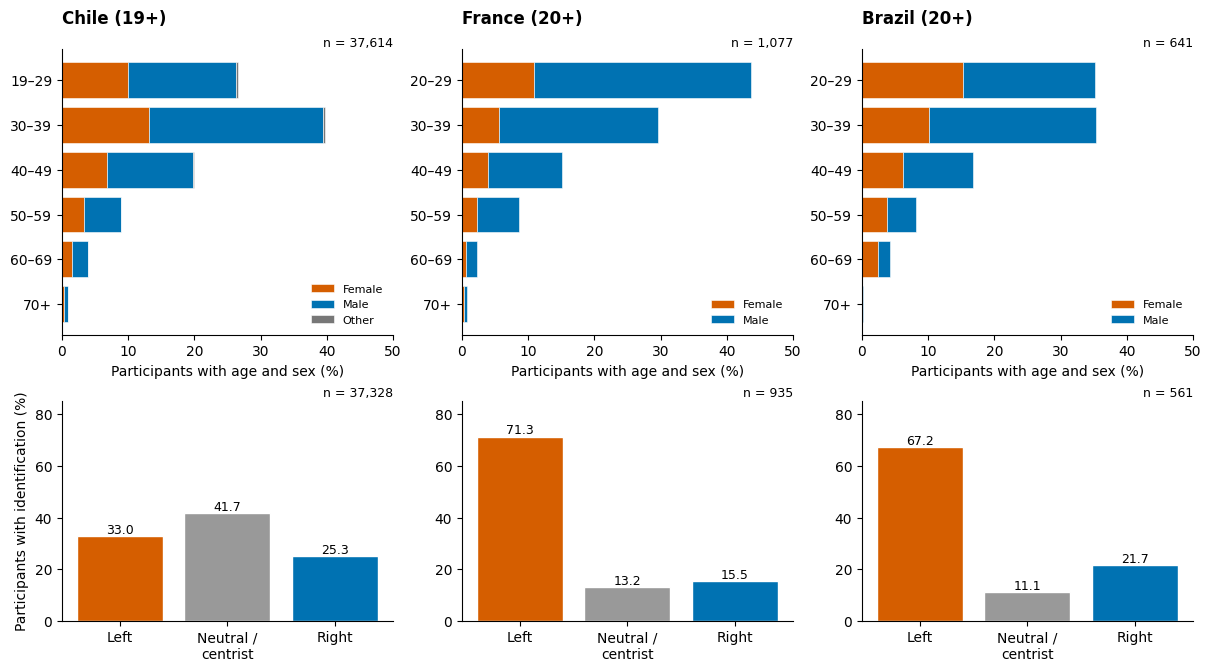

In [4]:
plt.rcParams.update({"font.size": 10, "font.family": "DejaVu Sans", "pdf.fonttype": 42})
fig, axes = plt.subplots(
    2, 3, figsize=(12, 6.6), gridspec_kw={"height_ratios": [1.3, 1]}, layout="constrained"
)
colors = {"Female": "#D55E00", "Male": "#0072B2", "Other": "#777777"}
max_age_share = max(
    counts.sum(axis=1).max() / counts.to_numpy().sum() * 100 for counts, _ in panels.values()
)
age_axis_limit = 5 * np.ceil(max_age_share * 1.08 / 5)
for col, (country, (age_counts, group_counts)) in enumerate(panels.items()):
    ax = axes[0, col]
    age_labels = AGE_LABELS[country]
    y = np.arange(len(age_labels))
    total = age_counts.to_numpy().sum()
    bottom = np.zeros(len(y))
    for sex in SEX_LABELS:
        values = age_counts[sex].to_numpy() / total * 100
        if values.sum() == 0:
            continue
        ax.barh(
            y,
            values,
            left=bottom,
            color=colors[sex],
            edgecolor="white",
            linewidth=0.4,
            label=sex,
        )
        bottom += values
    ax.set_yticks(y, age_labels)
    ax.invert_yaxis()
    ax.set_xlabel("Participants with age and sex (%)")
    ax.text(
        0,
        1.09,
        f"{country} ({MINIMUM_AGE[country]}+)",
        transform=ax.transAxes,
        weight="bold",
        fontsize=12,
    )
    ax.text(1, 1.01, f"n = {int(total):,}", transform=ax.transAxes, ha="right", fontsize=9)
    ax.set_xlim(0, age_axis_limit)
    ax.legend(frameon=False, fontsize=8, loc="lower right")
    ax.spines[["top", "right"]].set_visible(False)
    ax = axes[1, col]
    values = group_counts.to_numpy() / group_counts.sum() * 100
    ax.bar(np.arange(3), values, color=["#D55E00", "#999999", "#0072B2"], edgecolor="white")
    ax.set_xticks(np.arange(3), ["Left", "Neutral /\ncentrist", "Right"])
    ax.set_ylim(0, 85)
    ax.set_ylabel("Participants with identification (%)" if col == 0 else "")
    ax.text(
        1,
        1.02,
        f"n = {int(group_counts.sum()):,}",
        transform=ax.transAxes,
        ha="right",
        fontsize=9,
    )
    for x, value in enumerate(values):
        ax.text(x, value + 1, f"{value:.1f}", ha="center", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
display(fig)
fig.savefig(OUTPUT / "Fig1.pdf", facecolor="white", bbox_inches="tight")
fig.savefig(OUTPUT / "Fig1.png", facecolor="white", bbox_inches="tight", dpi=200)
plt.close(fig)
